In [1]:
## PARTE PARA LIMPIEZA DE LOS DATOS (en especial para el año 2023 >:\ )
## No es necesario correrlo mas de una vez al empezar asi que salta este chunk

import os
import re
import glob
import shutil
import pandas as pd
import pyreadstat
from contextlib import redirect_stdout
from unidecode import unidecode

PROJECT_ROOT = os.path.abspath(".")  
DATA_DIR     = os.path.join(PROJECT_ROOT, "data")
OUT_DIR      = os.path.join(PROJECT_ROOT, "processed")

HECHOS_OUT   = os.path.join(OUT_DIR, "hechos_combinado.csv")
VEH_OUT      = os.path.join(OUT_DIR, "vehiculos_combinado.csv")
FL_OUT       = os.path.join(OUT_DIR, "fl_combinado.csv")
MANIFEST     = os.path.join(OUT_DIR, "manifest.log")

def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

ensure_dir(OUT_DIR)

MESES = {1:"enero",2:"febrero",3:"marzo",4:"abril",5:"mayo",6:"junio",7:"julio",8:"agosto",9:"septiembre",10:"octubre",11:"noviembre",12:"diciembre"}
DIAS  = {1:"lunes",2:"martes",3:"miercoles",4:"jueves",5:"viernes",6:"sabado",7:"domingo"}
FRANJA_HORA = {0:"null",1:"00:00 a 05:59",2:"06:00 a 11:59",3:"12:00 a 17:59",4:"18:00 a 23:59",99:"ignorado"}
RANGO_ANIO_DICT = {1:"1970-1979",2:"1980-1989",3:"1990-1999",4:"2000-2009",5:"2010-2019",6:"2020-2029",99:"ignorado"}
MAYOR_MENOR_MAPPING = {1:"mayor",2:"menor",9:"ignorado"}
SEXO_DICT = {1:"hombre",2:"mujer",9:"ignorado"}
MODEL_VEH_IGNORADO = 9999
MARCAS = {1:"ahm",2:"tvs apache",3:"asia hero",4:"audi",5:"avanti",6:"bajaj",7:"blue bird",8:"bmw",9:"changan",10:"chevrolet",11:"chrysler",12:"daewoo",13:"daihatsu",14:"datsun",15:"dodge",16:"fiat",17:"ford",18:"freedom",19:"freightliner",20:"genesis",21:"geo",22:"alfa romeo",23:"gmc",24:"great wall",25:"hero hunk",26:"hino",27:"honda",28:"hyundai",29:"infiniti",30:"internacional",31:"isuzu",32:"italika",33:"jaguar",34:"jeep",35:"jialing",36:"john deere",37:"jumbo",38:"kawasaki",39:"keeway",40:"kenworth",41:"kia",42:"kinlon",43:"kymco",44:"land rover",45:"loncin",46:"mahindra",47:"lexus",48:"mazda",49:"mci",50:"mercedes benz",51:"mini cooper",52:"mitsubishi",53:"motolansa",54:"movesa",55:"porche",56:"nissan",57:"peter bilt",58:"peugeot",59:"piaggio",60:"plymouth",61:"renault",62:"rhino",63:"sanyang",64:"serpento",65:"soprano",66:"subaru",67:"suzuki",68:"sym",69:"toyota",70:"cadillac",71:"harley davidson",72:"united motors (um)",73:"volkswagen",74:"volvo",75:"wuling",76:"yamaha",77:"yumbo dakar",78:"ferrari",79:"seat",80:"autoriksha",81:"eagle flight",83:"honlei",84:"jac",85:"jinbei",86:"hummer",87:"x-bow krm",88:"mack",89:"pontiac",90:"scion",91:"zx auto",92:"sterling",93:"yiben",94:"ritchie bros",95:"chery destiny",96:"vento",97:"citroen",98:"dayun",99:"jmc",100:"haojue",101:"hyosung",102:"jincheng",103:"lifan",104:"macat",105:"pegasus",106:"rolls royse",107:"acura",108:"kingo",109:"raybar",110:"regent",111:"sing",112:"shineray",113:"skigo",114:"tough",115:"wuyang",116:"caterpillar",117:"opel",118:"scrambler",119:"mercury",120:"saturn corporation",121:"byd",122:"lincoln",123:"shimano",124:"vecesa",125:"dayang",126:"dinamo",127:"dpv dover",128:"faw jiabao",129:"fisher",130:"frontier",131:"makiba",132:"motinsa",133:"kinroad",134:"qingqi",135:"transmetro",136:"wanfeng",137:"cadisa",138:"ssangyong",139:"daelim",140:"bashan",141:"zongshen",142:"sukida",143:"chongqing",144:"foton",145:"chana",146:"prymouth",147:"aprilia",148:"fastran",149:"skoda",150:"mustang",151:"geely",152:"daifo",153:"workman",154:"forward",155:"king long",156:"automosa",157:"gac gonow",158:"ud trucks",159:"scania",160:"new holland",161:"freeway",162:"keiko",163:"benelli",164:"jetix",165:"tmr sl",166:"ape city",167:"brigadier",168:"mrt",169:"oldsmobile",170:"ktm",171:"bmx",172:"senke",173:"cf moto",174:"busscar",175:"sinotruk",176:"sanlg",177:"jiangsu sinki",178:"berliet",179:"aurus senat",180:"fruehauf",181:"kioti",182:"maya tour",183:"sanya",184:"triumph",185:"kenton",186:"skygo",187:"great dane",188:"phenix",189:"segway",190:"otros",999:"ignorado"}

tipoV_2013_2015 = {1:"automovil",2:"camioneta",3:"pick up",4:"motocicleta",5:"camion",6:"cabezal",7:"bus extraurbano",8:"jeep",9:"microbus",10:"taxi",11:"panel",12:"bus urbano",13:"tractor",14:"mototaxi",15:"furgon",16:"grua",17:"bus escolar",18:"bicicleta",99:"ignorado"}
tipoV_2016 = {1:"automovil",2:"camioneta sport o blazer",3:"pick up",4:"motocicleta",5:"camion",6:"cabezal",7:"bus extraurbano",8:"jeep",9:"microbus",10:"taxi",11:"panel",12:"bus urbano",13:"tractor",14:"mototaxi",15:"furgon",16:"grua",17:"bus escolar",18:"bicicleta",99:"ignorado"}
tipoV_2017 = {1:"automovil",2:"camioneta sport o blazer",3:"pick up",4:"motocicleta",5:"camion",6:"cabezal",7:"bus extraurbano",8:"jeep",9:"microbus",10:"taxi",11:"panel",12:"bus urbano",13:"tractor",14:"mototaxi",15:"furgon",16:"grua",17:"bus escolar",18:"bicicleta",19:"avioneta",20:"montacargas",21:"bus militar",22:"cuatrimoto",99:"ignorado"}
tipoV_2018_2020 = {1:"automovil",2:"camioneta sport o blazer",3:"pick up",4:"motocicleta",5:"camion",6:"cabezal",7:"bus extraurbano",8:"jeep",9:"microbus",10:"taxi",11:"panel",12:"bus urbano",13:"tractor",14:"mototaxi",15:"furgon",16:"grua",17:"bus escolar",18:"bicicleta",19:"avioneta",20:"montacargas",21:"bus militar",22:"cuatrimoto",23:"furgoneta",99:"ignorado"}
tipoV_2021 = {1:"automovil",2:"camioneta",3:"pick up",4:"motocicleta",5:"camion",6:"cabezal",7:"bus extraurbano",8:"jeep",9:"microbus",10:"taxi",11:"panel",12:"bus urbano",13:"tractor",14:"mototaxi",15:"furgon",16:"grua",17:"bus escolar",18:"bicicleta",19:"avioneta",20:"montacargas",21:"bus militar",22:"cuatrimoto",23:"furgoneta",99:"ignorado"}

accidentes_2013 = {1:"colision",2:"choque",3:"vuelco",4:"caida",11:"atropello",99:"ignorado"}
accidentes_2014_2017 = {1:"colision",2:"choque",3:"vuelco",4:"caida",5:"atropello",6:"perdida de control",7:"colision contra animal",8:"exceso de pasaje",9:"asfalto mojado",10:"exceso de velocidad",11:"desperfectos mecanicos",12:"incendio",99:"ignorado"}
accidentes_2018_2020 = {1:"colision",2:"choque",3:"vuelco",4:"caida",5:"atropello",6:"derrape",7:"embarranco",8:"encuneto",99:"ignorado"}
accidentes_2021 = {1:"colision",2:"choque",3:"vuelco",4:"caida",5:"atropello",6:"derrape",7:"desprendimiento",8:"incendio",9:"ataque armado",99:"ignorado"}

g_edad_2013 = {1:"menor de 15",2:"15-19",3:"20-24",4:"25-29",5:"30-34",6:"35-39",7:"40-44",8:"45-49",9:"50-54",10:"55 y mas"}
g_edad_2014 = {1:"menor de 15",2:"15-19",3:"20-24",4:"25-29",5:"30-34",6:"35-39",7:"40-44",8:"45-49",9:"50-54",10:"55-59",11:"60 y mas",12:"ignorado"}
g_edad_60ymas = {1:"menor de 15",2:"15-19",3:"20-24",4:"25-29",5:"30-34",6:"35-39",7:"40-44",8:"45-49",9:"50-54",10:"55-59",11:"60 y mas",12:"ignorado"}
g_edad_80ymas = {1:"menor de 15",2:"15-19",3:"20-24",4:"25-29",5:"30-34",6:"35-39",7:"40-44",8:"45-49",9:"50-54",10:"55-59",11:"60-64",12:"65-69",13:"70-74",14:"75-80",15:"80 y mas",16:"ignorado"}

edad_map = {2013:{"g_edad":g_edad_2013}, 2014:{"g_edad":g_edad_2014}}
for _anio in range(2015, 2022):
    edad_map[_anio] = {"g_edad_60ymas":g_edad_60ymas,"g_edad_80ymas":g_edad_80ymas}

estadoCond_2013_2017 = {1:"no ebrio",2:"ebrio",3:"drogado",9:"ignorado"}
estadoCond_2018_2021 = {1:"no ebrio",2:"ebrio",9:"ignorado"}

color_2013_2017 = {1:"rojo", 2:"blanco", 3:"azul", 4:"gris", 5:"negro", 6:"verde", 7:"amarillo", 8:"celeste", 9:"corinto", 10:"cafe", 11:"beige", 12:"turquesa", 13:"marfil", 14:"anaranjado", 15:"aqua", 16:"morado", 17:"rosado", 99:"ignorado"}
color_2018_2021 = {1:"rojo", 2:"blanco", 3:"azul", 4:"gris", 5:"negro", 6:"verde", 7:"amarillo", 8:"celeste", 9:"corinto", 10:"cafe", 11:"beige", 12:"turquesa", 13:"marfil", 14:"anaranjado", 15:"morado", 16:"rosado", 17:"varios colores", 99:"ignorado"}

fal_les_map   = {1:"fallecimiento", 2:"lesionado"}
internado_map = {1:"internado", 2:"no internado", 9:"ignorado"}

import unidecode as _unidecode

def unidec(s):  # corto
    return _unidecode.unidecode(str(s)) if s is not None else ""

def normalize_text(text):
    if pd.isna(text):
        return ""
    return _unidecode.unidecode(str(text)).lower().strip()

def extract_year_from_filename(filename):
    m = re.search(r'(\d{4})', filename)
    return int(m.group(1)) if m else None

def normalize_mes_dia(value, tipo="mes", year=None):
    if year is None or pd.isna(value):
        return pd.NA
    try:
        iv = int(float(value))
    except:
        return normalize_text(value)
    if tipo == "mes":
        return MESES.get(iv, pd.NA) if 2013 <= year <= 2021 else normalize_text(value)
    if tipo == "dia":
        return DIAS.get(iv, pd.NA) if 2013 <= year <= 2021 else normalize_text(value)
    return value

def normalize_g_hora(value, year=None):
    if pd.isna(value) or value == "": return 0
    if year is None: return value
    if 2013 <= year <= 2021:
        try: return int(value)
        except: return 0
    if 2022 <= year <= 2023:
        v = str(value).strip().lower()
        for k, txt in FRANJA_HORA.items():
            if v == txt.lower(): return k
        return 0
    return value

def normalize_zona(value):
    if pd.isna(value): return pd.NA
    v = normalize_text(value)
    if v in ["ignorada","ignorado"]: return 99
    try: return int(v)
    except: return pd.NA

def normalize_anio_ocu(df: pd.DataFrame):
    if "ano_ocu" in df.columns:
        df["anio_ocu_dataset"] = df["ano_ocu"]
        df["anio_ocu"] = df["ano_ocu"]
    else:
        df["anio_ocu_dataset"] = pd.NA
        df["anio_ocu"] = pd.NA
    if "anio_ocu_file" in df.columns:
        df["anio_ocu"] = df["anio_ocu"].fillna(df["anio_ocu_file"])
    if "ano_ocu" in df.columns:
        df.drop(columns=["ano_ocu"], inplace=True)
    return df

def map_accidente_year(tipo_eve, anio):
    if anio in [2022, 2023]:
        val = unidec(str(tipo_eve).lower().strip())
        fixups = {"colisi?n": "colision", "ca?da": "caida", "embarranc?": "embarranco", "encunet?": "encuneto"}
        for k,v in fixups.items():
            if k in val: val = val.replace(k, v)
        val = val.replace("?", "")
        return val if val else "ignorado"
    try:
        code = int(float(tipo_eve))
    except:
        txt = unidec(str(tipo_eve).lower().strip())
        return txt if txt else "ignorado"
    if anio == 2013: return accidentes_2013.get(code,"ignorado")
    if anio in [2014,15,16,17]: return accidentes_2014_2017.get(code,"ignorado")
    if anio in [2018,19,20]:    return accidentes_2018_2020.get(code,"ignorado")
    if anio == 2021:            return accidentes_2021.get(code,"ignorado")
    return "ignorado"

def map_tipo_veh_year(tipo_veh, anio):
    if pd.isna(tipo_veh): return pd.NA
    if anio in [2022, 2023]:
        val = unidec(str(tipo_veh).lower().strip())
        reempl = {"autom?vil":"automovil","cami?n":"camion","microb?s":"microbus","furg?n":"furgon","gr?a":"grua","motos acua?ticas":"motos acuaticas"}
        for k,v in reempl.items():
            if k in val: val = val.replace(k, v)
        return val
    try:
        iv = int(float(tipo_veh))
    except:
        return str(tipo_veh).lower().strip()
    if anio in [2013,14,15]: return tipoV_2013_2015.get(iv, str(tipo_veh).lower().strip())
    if anio == 2016:         return tipoV_2016.get(iv, str(tipo_veh).lower().strip())
    if anio == 2017:         return tipoV_2017.get(iv, str(tipo_veh).lower().strip())
    if anio in [2018,19,20]: return tipoV_2018_2020.get(iv, str(tipo_veh).lower().strip())
    if anio == 2021:         return tipoV_2021.get(iv, str(tipo_veh).lower().strip())
    return str(tipo_veh).lower().strip()

def map_color_veh_year(color_veh, anio):
    if pd.isna(color_veh): return pd.NA
    if anio in [2022, 2023]:
        val = unidec(str(color_veh).lower().strip())
        if "caf?e" in val: val = val.replace("caf?e", "cafe")
        return val
    try:
        iv = int(float(color_veh))
    except:
        return str(color_veh).lower().strip()
    if anio in [2013,14,15,16,17]: return color_2013_2017.get(iv, str(color_veh).lower().strip())
    if anio in [2018,19,20,21]:   return color_2018_2021.get(iv, str(color_veh).lower().strip())
    return str(color_veh).lower().strip()

def map_modelo_veh_year(modelo_veh, anio):
    if pd.isna(modelo_veh): return pd.NA
    if anio in [2022, 2023]:
        val = unidec(str(modelo_veh).lower().strip())
        if val == "ignorado": return MODEL_VEH_IGNORADO
        try: return int(val)
        except: return pd.NA
    try: return int(float(modelo_veh))
    except: return str(modelo_veh).lower().strip()

def map_marca_veh_year(marca_veh, anio):
    if pd.isna(marca_veh):
        return MARCAS[190] if anio in range(2013,2022) else pd.NA
    if anio in [2022, 2023]:
        return unidec(str(marca_veh).lower().strip())
    try:
        iv = int(float(marca_veh))
    except:
        return MARCAS[190]
    return MARCAS.get(iv, MARCAS[190])

def map_estado_con_year(estado, anio):
    if pd.isna(estado): return pd.NA
    if anio in [2022, 2023]: return unidec(str(estado).lower().strip())
    try:
        iv = int(float(estado))
    except:
        return str(estado).lower().strip()
    if anio in [2013,14,15,16,17]: return estadoCond_2013_2017.get(iv, "ignorado")
    if anio in [2018,19,20,21]:   return estadoCond_2018_2021.get(iv, "ignorado")
    return str(estado).lower().strip()

def map_grupo_anio_veh(value, anio):
    if pd.isna(value): return "ignorado"
    vs = str(value).strip()
    if anio in [2013,14,15,16,17]:
        if vs in ["6","9999"]: return "ignorado"
        try: return RANGO_ANIO_DICT.get(int(float(vs)), "ignorado")
        except: return "ignorado"
    if anio in [2018,19,20,21]:
        if vs == "99": return "ignorado"
        try: return RANGO_ANIO_DICT.get(int(float(vs)), "ignorado")
        except: return "ignorado"
    if anio in [2022,23]:
        vc = unidec(vs.lower())
        for k, v in RANGO_ANIO_DICT.items():
            if vc == v.lower(): return v
        return "ignorado" if vc == "ignorado" else vc
    return "ignorado"

def map_mayor_menor(valor, anio):
    if pd.isna(valor): return "ignorado"
    if anio in [2022,23]:
        if isinstance(valor,str):
            return (valor.lower()
                    .replace("á","a").replace("é","e").replace("í","i")
                    .replace("ó","o").replace("ú","u"))
        return str(valor)
    try:
        return MAYOR_MENOR_MAPPING.get(int(float(valor)), "ignorado")
    except:
        return "ignorado"

def map_sexo(value, anio):
    if anio is None or pd.isna(anio): return "ignorado"
    anio = int(anio)
    if pd.isna(value) or value == "": return "ignorado"
    if 2013 <= anio <= 2021:
        try: return SEXO_DICT.get(int(float(value)), "ignorado")
        except: return "ignorado"
    if 2022 <= anio <= 2023:
        val = unidec(str(value).strip().lower())
        return val if val in ["hombre","mujer"] else "ignorado"
    return "ignorado"

def map_edad(value, anio, df):
    if pd.isna(value): return "ignorado"
    if anio >= 2022: return unidec(str(value).lower())
    if anio in edad_map:
        col = None
        if anio in [2013, 2014]:
            col = "g_edad"
        else:
            if "g_edad_80ymas" in df.columns and pd.notna(df["g_edad_80ymas"].iloc[0]): col = "g_edad_80ymas"
            elif "g_edad_60ymas" in df.columns: col = "g_edad_60ymas"
        if col and col in edad_map[anio]:
            try:
                return unidec(str(edad_map[anio][col].get(int(value), "Ignorado")).lower())
            except:
                return "ignorado"
    return "ignorado"

def map_fall_les(valor, anio):
    try:
        y = int(float(anio))
    except:
        return "ignorado"
    if valor is None or str(valor).strip()=="":
        return "ignorado"
    txt = unidecode(str(valor).lower()).strip()
    if 2013 <= y <= 2021:
        try:
            return fal_les_map.get(int(float(valor)), "ignorado")
        except:
            return "ignorado"
        return "ignorado"
    elif 2022 <= y <= 2023:
        if txt in {"1","1.0","1,0"}: return "fallecimiento"
        if txt in {"2","2.0","2,0"}: return "lesionado"
        if txt in {"3","3.0","3,0"}: return "ignorado"
        if "fallec" in txt: return "fallecimiento"
        if "les"    in txt: return "lesionado"
        return "ignorado"
    else:
        return "ignorado"


def normalize_internado(value, year):
    if pd.isna(value) or str(value).strip() == "": return "ignorado"
    try: year = int(year)
    except: return "ignorado"
    if year in [2013,2014]: return "ignorado"
    if 2015 <= year <= 2021:
        try: return internado_map.get(int(float(value)), "ignorado")
        except: return "ignorado"
    if year in [2022,2023]: return unidec(str(value).strip().lower())
    return "ignorado"


def read_any(path: str) -> pd.DataFrame:
    if path.lower().endswith(".sav"):
        df, _meta = pyreadstat.read_sav(path)
        return df
    if path.lower().endswith((".xlsx", ".xls")):
        return pd.read_excel(path)
    raise ValueError(f"Formato no soportado: {path}")

def try_map_depto_mupio(df: pd.DataFrame) -> pd.DataFrame:
    dep_csv = os.path.join(DATA_DIR, "departamentos.csv")
    muni_csv = os.path.join(DATA_DIR, "municipios.csv")
    if not (os.path.exists(dep_csv) and os.path.exists(muni_csv)):
        # No hay catálogos -> devolver sin cambios
        return df
    df_deptos = pd.read_csv(dep_csv, encoding="utf-8")
    df_mupios = pd.read_csv(muni_csv, encoding="utf-8")
    depto_map = {normalize_text(r["departamento"]): r["codigo"] for _, r in df_deptos.iterrows()}
    muni_map  = {normalize_text(r["municipio"]):     r["codigo"] for _, r in df_mupios.iterrows()}

    def match_partial(val, catalog):
        if pd.isna(val): return pd.NA
        try: return int(val)
        except:
            val_norm = normalize_text(val)
            for key_norm, code in catalog.items():
                L = min(len(val_norm), len(key_norm))
                if L >= 3 and val_norm[:L] == key_norm[:L]:
                    return code
            return pd.NA

    if "depto_ocu" in df.columns:
        df["depto_ocu"] = df["depto_ocu"].apply(lambda x: match_partial(x, depto_map))
        df["depto_ocu"] = pd.to_numeric(df["depto_ocu"], errors="coerce").astype("Int64")
    if "mupio_ocu" in df.columns:
        df["mupio_ocu"] = df["mupio_ocu"].apply(lambda x: match_partial(x, muni_map))
        df["mupio_ocu"] = pd.to_numeric(df["mupio_ocu"], errors="coerce").astype("Int64")
    return df

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [c.lower()
                    .replace("á","a").replace("é","e").replace("í","i")
                    .replace("ó","o").replace("ú","u").replace("ñ","n")
                    .strip() for c in df.columns]
    return df

def fill_correlativo(df: pd.DataFrame) -> pd.DataFrame:
    cols = [c for c in ["num_hecho","num_corre","num_correlativo"] if c in df.columns]
    if cols:
        df["num_corre"] = df[cols].bfill(axis=1).iloc[:,0]
    else:
        df["num_corre"] = pd.NA
    return df

def normalize_time_parts(df: pd.DataFrame, year_col="anio_ocu_file") -> pd.DataFrame:
    if "mes_ocu" in df.columns:
        df["mes_ocu"] = df.apply(lambda x: normalize_mes_dia(x["mes_ocu"], "mes", x[year_col]), axis=1)
    if "dia_sem_ocu" in df.columns:
        df["dia_sem_ocu"] = df.apply(lambda x: normalize_mes_dia(x["dia_sem_ocu"], "dia", x[year_col]), axis=1)
    if "g_hora" in df.columns:
        df["g_hora"] = df.apply(lambda x: normalize_g_hora(x["g_hora"], x[year_col]), axis=1)
    if "zona_ocu" in df.columns:
        df["zona_ocu"] = df["zona_ocu"].apply(normalize_zona)
    return df

def drop_dupe_cols(df: pd.DataFrame, extra_drop=None) -> pd.DataFrame:
    drops = ["num_hecho","num_correlativo","g_hora_5"]
    if extra_drop:
        drops.extend(extra_drop)
    df.drop(columns=[c for c in drops if c in df.columns], inplace=True, errors="ignore")
    df = df.loc[:, ~df.columns.duplicated()]
    return df

def combine_hechos():
    files = sorted([p for p in glob.glob(os.path.join(DATA_DIR, "hechos_*.*")) if p.lower().endswith((".sav",".xlsx",".xls"))])
    if not files:
        print("[HECHOS] No se encontraron archivos.")
        return pd.DataFrame()
    combined = pd.DataFrame()
    last_num = 0
    for path in files:
        year = extract_year_from_filename(os.path.basename(path))
        df = read_any(path)
        df = standardize_columns(df)

        if "causa_acc" in df.columns and "tipo_eve" in df.columns:
            df["tipo_eve"] = df["tipo_eve"].combine_first(df["causa_acc"])
            df.drop(columns=["causa_acc"], inplace=True)
        elif "causa_acc" in df.columns:
            df["tipo_eve"] = df["causa_acc"]
            df.drop(columns=["causa_acc"], inplace=True)

        drop_cols_initial = ["corre_base","dia_ocu","edad_quinquenales","zona_ciudad",
                             "areag_ocu","area_geo_ocu","sexo","sexo_con","sexo_per","sexo_pil",
                             "departamento","municipio","edad_pil","g_edad_2","edad_con",
                             "g_edad","edad_per","g_edad_80ymas","g_edad_60ymas","mayor_menor",
                             "g_modelo_veh","estado_con","estado_pil"]
        df.drop(columns=[c for c in drop_cols_initial if c in df.columns], inplace=True, errors="ignore")

        df["anio_ocu_file"] = year

        if "tipo_eve"  in df.columns: df["tipo_eve"]  = df.apply(lambda x: map_accidente_year(x["tipo_eve"],  x["anio_ocu_file"]), axis=1)
        if "tipo_veh"  in df.columns: df["tipo_veh"]  = df.apply(lambda x: map_tipo_veh_year(x["tipo_veh"],  x["anio_ocu_file"]), axis=1)
        if "color_veh" in df.columns: df["color_veh"] = df.apply(lambda x: map_color_veh_year(x["color_veh"],x["anio_ocu_file"]), axis=1)
        if "modelo_veh" in df.columns: df["modelo_veh"] = df.apply(lambda x: map_modelo_veh_year(x["modelo_veh"],x["anio_ocu_file"]), axis=1)
        if "marca_veh"  in df.columns: df["marca_veh"]  = df.apply(lambda x: map_marca_veh_year(x["marca_veh"], x["anio_ocu_file"]), axis=1)
        if "mayor_menor" in df.columns: df["mayor_menor"] = df.apply(lambda x: map_mayor_menor(x["mayor_menor"], x["anio_ocu_file"]), axis=1)

        df = fill_correlativo(df)
        df = normalize_time_parts(df)
        df = drop_dupe_cols(df)

        # correlativo acumulado
        df["num_corre"] = df["num_corre"].fillna(0) + last_num
        last_num = df["num_corre"].max()

        df = normalize_anio_ocu(df)
        df = try_map_depto_mupio(df)

        combined = pd.concat([combined, df], ignore_index=True, sort=False)
        print(f"[HECHOS] {os.path.basename(path)} -> filas: {len(df)}")
    return combined

def combine_vehiculos():
    files = sorted([p for p in glob.glob(os.path.join(DATA_DIR, "vehiculos_*.*")) if p.lower().endswith((".sav",".xlsx",".xls"))])
    if not files:
        print("[VEHICULOS] No se encontraron archivos.")
        return pd.DataFrame()
    combined = pd.DataFrame()
    last_num = 0
    for path in files:
        year = extract_year_from_filename(os.path.basename(path))
        df = read_any(path)
        df = standardize_columns(df)

        # Limpiezas y unificaciones
        drop_cols_initial = ["corre_base","dia_ocu","edad_quinquenales","zona_ciudad","areag_ocu","area_geo_ocu","departamento","municipio"]
        df.drop(columns=[c for c in drop_cols_initial if c in df.columns], inplace=True, errors="ignore")

        # causa_acc -> tipo_eve
        if "causa_acc" in df.columns and "tipo_eve" in df.columns:
            df["tipo_eve"] = df["tipo_eve"].combine_first(df["causa_acc"]); df.drop(columns=["causa_acc"], inplace=True)
        elif "causa_acc" in df.columns:
            df["tipo_eve"] = df["causa_acc"]; df.drop(columns=["causa_acc"], inplace=True)

        # estado_pil -> estado_con (2013)
        if "estado_pil" in df.columns:
            if year == 2013:
                if "estado_con" not in df.columns: df["estado_con"] = df["estado_pil"]
                else: df["estado_con"] = df["estado_con"].combine_first(df["estado_pil"])
            df.drop(columns=["estado_pil"], inplace=True)

        # grupo_mode_veh -> g_modelo_veh (2013–2014)
        if "grupo_mode_veh" in df.columns:
            if year in [2013, 2014]:
                if "g_modelo_veh" not in df.columns: df["g_modelo_veh"] = df["grupo_mode_veh"]
                else: df["g_modelo_veh"] = df["g_modelo_veh"].combine_first(df["grupo_mode_veh"])
            df.drop(columns=["grupo_mode_veh"], inplace=True)

        # sex_cond unificado
        if any(c in df.columns for c in ["sexo_pil","sexo_con","sexo_per"]):
            if "sex_cond" not in df.columns: df["sex_cond"] = pd.NA
            if "sexo_pil" in df.columns: df["sex_cond"] = df["sex_cond"].combine_first(df["sexo_pil"])
            if "sexo_con" in df.columns: df["sex_cond"] = df["sex_cond"].combine_first(df["sexo_con"])
            if "sexo_per" in df.columns: df["sex_cond"] = df["sex_cond"].combine_first(df["sexo_per"])
            df.drop(columns=[c for c in ["sexo_pil","sexo_con","sexo_per"] if c in df.columns], inplace=True)

        if any(c in df.columns for c in ["edad_pil","edad_con","edad_per"]):
            if "edad_con" not in df.columns: df["edad_con"] = pd.NA
            if "edad_pil" in df.columns: df["edad_con"] = df["edad_con"].combine_first(df["edad_pil"])
            if "edad_per" in df.columns: df["edad_con"] = df["edad_con"].combine_first(df["edad_per"])
            def safe_int(x):
                try: return int(float(x))
                except: return -1
            df["edad_con"] = df["edad_con"].apply(safe_int)
            df.drop(columns=[c for c in ["edad_pil","edad_per"] if c in df.columns], inplace=True)

        if any(c in df.columns for c in ["g_edad","g_edad_60ymas","g_edad_80ymas"]):
            df["edad_con_grupo"] = pd.NA
            for c in ["g_edad","g_edad_60ymas","g_edad_80ymas"]:
                if c in df.columns:
                    df["edad_con_grupo"] = df["edad_con_grupo"].combine_first(df[c])
            df["edad_con_grupo"] = df.apply(lambda x: map_edad(x["edad_con_grupo"], year, df), axis=1)
            df["edad_con_grupo"] = df["edad_con_grupo"].apply(lambda x: unidec(str(x).lower()))
            df.drop(columns=[c for c in ["g_edad","g_edad_60ymas","g_edad_80ymas"] if c in df.columns], inplace=True)

        df["anio_ocu_file"] = year

        if "tipo_eve" in df.columns:   df["tipo_eve"]   = df.apply(lambda x: map_accidente_year(x["tipo_eve"],   x["anio_ocu_file"]), axis=1)
        if "tipo_veh" in df.columns:   df["tipo_veh"]   = df.apply(lambda x: map_tipo_veh_year(x["tipo_veh"],   x["anio_ocu_file"]), axis=1)
        if "color_veh" in df.columns:  df["color_veh"]  = df.apply(lambda x: map_color_veh_year(x["color_veh"], x["anio_ocu_file"]), axis=1)
        if "modelo_veh" in df.columns: df["modelo_veh"] = df.apply(lambda x: map_modelo_veh_year(x["modelo_veh"],x["anio_ocu_file"]), axis=1)
        if "marca_veh" in df.columns:  df["marca_veh"]  = df.apply(lambda x: map_marca_veh_year(x["marca_veh"], x["anio_ocu_file"]), axis=1)
        if "estado_con" in df.columns: df["estado_con"] = df.apply(lambda x: map_estado_con_year(x["estado_con"],x["anio_ocu_file"]), axis=1)

        if "g_modelo_veh" not in df.columns: df["g_modelo_veh"] = pd.NA
        df["g_modelo_veh"] = (df["g_modelo_veh"].replace([""," ","null","NULL","nan","NaN","none","None"], pd.NA))
        df["g_modelo_veh"] = df.apply(lambda x: map_grupo_anio_veh(x["g_modelo_veh"], x["anio_ocu_file"]), axis=1)

        if "sex_cond" in df.columns:    df["sex_cond"]    = df.apply(lambda x: map_sexo(x["sex_cond"],    x["anio_ocu_file"]), axis=1)
        if "mayor_menor" in df.columns: df["mayor_menor"] = df.apply(lambda x: map_mayor_menor(x["mayor_menor"], x["anio_ocu_file"]), axis=1)

        df = fill_correlativo(df)
        df = normalize_time_parts(df)
        df = drop_dupe_cols(df)

        df["num_corre"] = df["num_corre"].fillna(0) + last_num
        last_num = df["num_corre"].max()

        df = normalize_anio_ocu(df)
        df = try_map_depto_mupio(df)

        combined = pd.concat([combined, df], ignore_index=True, sort=False)
        print(f"[VEHICULOS] {os.path.basename(path)} -> filas: {len(df)}")
    return combined

def combine_fl():
    files = sorted([p for p in glob.glob(os.path.join(DATA_DIR, "fallecidos_*.*")) if p.lower().endswith((".sav",".xlsx",".xls"))])
    if not files:
        print("[FL] No se encontraron archivos de fallecidos_.")
        return pd.DataFrame()
    combined = pd.DataFrame()
    last_num = 0
    for path in files:
        year = extract_year_from_filename(os.path.basename(path))
        df = read_any(path)
        df = standardize_columns(df)

        drop_cols_initial = ["corre_base","dia_ocu","edad_quinquenales","zona_ciudad",
                             "areag_ocu","area_geo_ocu","departamento","municipio",
                             "otro_g_edad_fall_les","g_edad_2","edad_pil","g_modelo_veh","sexo_pil"]
        df.drop(columns=[c for c in drop_cols_initial if c in df.columns], inplace=True, errors="ignore")

        if "causa_acc" in df.columns and "tipo_eve" in df.columns:
            df["tipo_eve"] = df["tipo_eve"].combine_first(df["causa_acc"]); df.drop(columns=["causa_acc"], inplace=True)
        elif "causa_acc" in df.columns:
            df["tipo_eve"] = df["causa_acc"]; df.drop(columns=["causa_acc"], inplace=True)

        if "estado_pil" in df.columns:
            if year == 2013:
                if "estado_con" not in df.columns: df["estado_con"] = df["estado_pil"]
                else: df["estado_con"] = df["estado_con"].combine_first(df["estado_pil"])
            df.drop(columns=["estado_pil"], inplace=True)

        if any(c in df.columns for c in ["sexo_vic","sexo_per"]):
            if "sexo_vic" not in df.columns: df["sexo_vic"] = pd.NA
            if "sexo_per" in df.columns: df["sexo_vic"] = df["sexo_vic"].combine_first(df["sexo_per"])
            df.drop(columns=[c for c in ["sexo_per"] if c in df.columns], inplace=True)

        if any(c in df.columns for c in ["edad_vic","edad_per"]):
            if "edad_vic" not in df.columns: df["edad_vic"] = pd.NA
            if "edad_per" in df.columns: df["edad_vic"] = df["edad_vic"].combine_first(df["edad_per"])
            def safe_int(x):
                try: return int(float(x))
                except: return -1
            df["edad_vic"] = df["edad_vic"].apply(safe_int)
            df.drop(columns=[c for c in ["edad_pil","edad_con","edad_per"] if c in df.columns], inplace=True)

        if any(c in df.columns for c in ["g_edad","g_edad_60ymas","g_edad_80ymas"]):
            df["edad_grupo"] = pd.NA
            for c in ["g_edad","g_edad_60ymas","g_edad_80ymas"]:
                if c in df.columns:
                    df["edad_grupo"] = df["edad_grupo"].combine_first(df[c])
            df["edad_grupo"] = df.apply(lambda x: map_edad(x["edad_grupo"], year, df), axis=1)
            df["edad_grupo"] = df["edad_grupo"].apply(lambda x: unidec(str(x).lower()))
            df.drop(columns=[c for c in ["g_edad","g_edad_60ymas","g_edad_80ymas"] if c in df.columns], inplace=True)

        if "fallecidos_lesionados" in df.columns:
            if year == 2013:
                if "fall_les" not in df.columns: df["fall_les"] = df["fallecidos_lesionados"]
                else: df["fall_les"] = df["fall_les"].combine_first(df["fallecidos_lesionados"])
            df.drop(columns=["fallecidos_lesionados"], inplace=True)

        df["anio_ocu_file"] = year

        if "tipo_eve" in df.columns:   df["tipo_eve"]   = df.apply(lambda x: map_accidente_year(x["tipo_eve"],   x["anio_ocu_file"]), axis=1)
        if "tipo_veh" in df.columns:   df["tipo_veh"]   = df.apply(lambda x: map_tipo_veh_year(x["tipo_veh"],   x["anio_ocu_file"]), axis=1)
        if "color_veh" in df.columns:  df["color_veh"]  = df.apply(lambda x: map_color_veh_year(x["color_veh"], x["anio_ocu_file"]), axis=1)
        if "modelo_veh" in df.columns: df["modelo_veh"] = df.apply(lambda x: map_modelo_veh_year(x["modelo_veh"],x["anio_ocu_file"]), axis=1)
        if "marca_veh" in df.columns:  df["marca_veh"]  = df.apply(lambda x: map_marca_veh_year(x["marca_veh"], x["anio_ocu_file"]), axis=1)
        if "estado_con" in df.columns: df["estado_con"] = df.apply(lambda x: map_estado_con_year(x["estado_con"],x["anio_ocu_file"]), axis=1)

        if "sexo_vic" not in df.columns: df["sexo_vic"] = pd.NA
        df["sexo_vic"] = df.apply(lambda x: map_sexo(x["sexo_vic"], x["anio_ocu_file"]), axis=1)

        if "mayor_menor" in df.columns:
            df["mayor_menor"] = df.apply(lambda x: map_mayor_menor(x["mayor_menor"], x["anio_ocu_file"]), axis=1)

        if "fall_les" not in df.columns: df["fall_les"] = pd.NA
        df["fall_les"] = df.apply(lambda x: map_fall_les(x["fall_les"], x["anio_ocu_file"]), axis=1)

        if "int_o_noint" not in df.columns: df["int_o_noint"] = pd.NA
        df["int_o_noint"] = df.apply(lambda x: normalize_internado(x["int_o_noint"], x["anio_ocu_file"]), axis=1)

        df = fill_correlativo(df)
        df = normalize_time_parts(df)
        df = drop_dupe_cols(df)

        df["num_corre"] = df["num_corre"].fillna(0) + last_num
        last_num = df["num_corre"].max()
        df["num_corre"] = df["num_corre"].astype(int)

        df = normalize_anio_ocu(df)
        df = try_map_depto_mupio(df)

        combined = pd.concat([combined, df], ignore_index=True, sort=False)
        print(f"[FL] {os.path.basename(path)} -> filas: {len(df)}")
    if "edad_vic" in combined.columns:
        combined["edad_vic"] = combined["edad_vic"].fillna(-1).apply(lambda x: int(float(x)) if str(x).strip() != "" else -1)
    return combined

def main():
    with open(MANIFEST, "w", encoding="utf-8") as mf:
        with redirect_stdout(mf):
            print("=== INICIO LIMPIEZA Y COMBINACIÓN ===")
            print(f"BASE: {DATA_DIR}")
            print("\n--- HECHOS ---")
            hechos = combine_hechos()
            if not hechos.empty:
                hechos.to_csv(HECHOS_OUT, index=False, encoding="utf-8")
                print(f"Guardado: {HECHOS_OUT}  shape={hechos.shape}")
            else:
                print("No se generó HECHOS combinado (sin archivos).")

            print("\n--- VEHICULOS ---")
            veh = combine_vehiculos()
            if not veh.empty:
                veh.to_csv(VEH_OUT, index=False, encoding="utf-8")
                print(f"Guardado: {VEH_OUT}  shape={veh.shape}")
            else:
                print("No se generó VEHICULOS combinado (sin archivos).")

            print("\n--- FALLECIDOS/LESIONADOS ---")
            fl = combine_fl()
            if not fl.empty:
                fl.to_csv(FL_OUT, index=False, encoding="utf-8")
                print(f"Guardado: {FL_OUT}  shape={fl.shape}")
            else:
                print("No se generó FL combinado (sin archivos).")

            print("\n=== FIN DEL PROCESO ===")

    # Mensaje al usuario en stdout
    print("Proceso completado.")
    print(f"- Manifest: {MANIFEST}")
    if os.path.exists(HECHOS_OUT): print(f"- HECHOS: {HECHOS_OUT}")
    if os.path.exists(VEH_OUT):    print(f"- VEHÍCULOS: {VEH_OUT}")
    if os.path.exists(FL_OUT):     print(f"- FL: {FL_OUT}")
main()


/tmp/ipykernel_10177/451015296.py:120: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["anio_ocu"] = df["anio_ocu"].fillna(df["anio_ocu_file"])
/tmp/ipykernel_10177/451015296.py:120: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["anio_ocu"] = df["anio_ocu"].fillna(df["anio_ocu_file"])
/tmp/ipykernel_10177/451015296.py:467: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entr

Proceso completado.
- Manifest: /home/gus/work/processed/manifest.log
- HECHOS: /home/gus/work/processed/hechos_combinado.csv
- VEHÍCULOS: /home/gus/work/processed/vehiculos_combinado.csv
- FL: /home/gus/work/processed/fl_combinado.csv


## Librerias

In [2]:
import os
from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.sql.window import Window
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler, PCA
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, RegressionEvaluator, ClusteringEvaluator
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression, DecisionTreeClassifier
from pyspark.ml import Pipeline, PipelineModel
import matplotlib.pyplot as plt
from pyspark.ml.feature import Imputer
from pyspark.ml.regression import LinearRegression

## Paths y configuración

In [3]:
BASE = "/home/gus/work/processed"
PARQ = os.path.join(BASE, "parquet")
os.makedirs(PARQ, exist_ok=True)

spark = (
    SparkSession.builder
    .appName("CC3066-Lab9-AEA-Segmentacion-Modelado")
    .getOrCreate()
)

spark.conf.set("spark.sql.shuffle.partitions", "200")
SEED = 33

# Utilidades
to_int = F.udf(lambda x: int(x) if x is not None else None, T.IntegerType())
to_double = F.udf(lambda x: float(x) if x is not None else None, T.DoubleType())

# Carga de los CSV combinados
hechos_csv = os.path.join(BASE, "hechos_combinado.csv")
veh_csv = os.path.join(BASE, "vehiculos_combinado.csv")
fl_csv = os.path.join(BASE, "fl_combinado.csv")

hechos_parq = os.path.join(PARQ, "hechos")
veh_parq = os.path.join(PARQ, "vehiculos")
fl_parq = os.path.join(PARQ, "fl")

if not os.path.exists(hechos_parq):
    df_hechos_raw = spark.read.option("header", True).option("inferSchema", True).csv(hechos_csv)
    df_hechos_raw.write.mode("overwrite").parquet(hechos_parq)

if not os.path.exists(veh_parq):
    df_veh_raw = spark.read.option("header", True).option("inferSchema", True).csv(veh_csv)
    df_veh_raw.write.mode("overwrite").parquet(veh_parq)

if not os.path.exists(fl_parq):
    df_fl_raw = spark.read.option("header", True).option("inferSchema", True).csv(fl_csv)
    df_fl_raw.write.mode("overwrite").parquet(fl_parq)

## Ejercicio 1

In [4]:
hechos = spark.read.parquet(hechos_parq)
veh = spark.read.parquet(veh_parq)
fl = spark.read.parquet(fl_parq)

hechos.printSchema()
veh.printSchema()
fl.printSchema()

hechos.show(5, truncate=False)
veh.show(5, truncate=False)
fl.show(5, truncate=False)

# Selección/normalización de llaves comunes
key_cols = [
    "anio_ocu", "mes_ocu", "dia_sem_ocu", "g_hora",
    "depto_ocu", "mupio_ocu", "zona_ocu", "tipo_eve"
]

def ensure_cols(df, cols):
    for c in cols:
        if c not in df.columns:
            df = df.withColumn(c, F.lit(None).cast("string"))
    return df

hechos = ensure_cols(hechos, key_cols)
veh = ensure_cols(veh, key_cols)
fl = ensure_cols(fl, key_cols)

def cast_for_keys(df):
    return (
        df
        .withColumn("anio_ocu", F.col("anio_ocu").cast("int"))
        .withColumn("g_hora", F.col("g_hora").cast("int"))
        .withColumn("depto_ocu", F.col("depto_ocu").cast("int"))
        .withColumn("mupio_ocu", F.col("mupio_ocu").cast("int"))
        .withColumn("zona_ocu", F.col("zona_ocu").cast("int"))
        .withColumn("tipo_eve", F.lower(F.col("tipo_eve")))
        .withColumn("mes_ocu", F.lower(F.col("mes_ocu")))
        .withColumn("dia_sem_ocu", F.lower(F.col("dia_sem_ocu")))
    )

hechos = cast_for_keys(hechos)
veh = cast_for_keys(veh)
fl = cast_for_keys(fl)

accidentes_g = (
    hechos.groupBy(*key_cols)
    .agg(F.count(F.lit(1)).alias("num_accidentes"))
)

vehiculos_g = (
    veh.groupBy(*key_cols)
    .agg(
        F.count(F.lit(1)).alias("num_vehiculos"),
        F.countDistinct("num_corre").alias("num_corre_distintos")
    )
)

fl_counts = (
    fl.withColumn("is_les", F.when(F.col("fall_les") == F.lit("lesionado"), 1).otherwise(0))
      .withColumn("is_fall", F.when(F.col("fall_les") == F.lit("fallecimiento"), 1).otherwise(0))
      .groupBy(*key_cols)
      .agg(
          F.sum("is_les").alias("num_lesionados"),
          F.sum("is_fall").alias("num_fallecidos")
      )
)

combined = (
    accidentes_g
    .join(vehiculos_g, on=key_cols, how="outer")
    .join(fl_counts, on=key_cols, how="outer")
    .fillna({"num_accidentes":0, "num_vehiculos":0, "num_corre_distintos":0, "num_lesionados":0, "num_fallecidos":0})
)

combined = combined.withColumn("hora_cod", F.col("g_hora").cast("int"))

combined.cache()
combined.write.mode("overwrite").parquet(os.path.join(PARQ, "combined"))

root
 |-- mes_ocu: string (nullable = true)
 |-- dia_sem_ocu: string (nullable = true)
 |-- hora_ocu: double (nullable = true)
 |-- g_hora: integer (nullable = true)
 |-- depto_ocu: double (nullable = true)
 |-- mupio_ocu: double (nullable = true)
 |-- zona_ocu: integer (nullable = true)
 |-- tipo_veh: string (nullable = true)
 |-- color_veh: string (nullable = true)
 |-- modelo_veh: integer (nullable = true)
 |-- marca_veh: string (nullable = true)
 |-- tipo_eve: string (nullable = true)
 |-- anio_ocu_file: integer (nullable = true)
 |-- num_corre: double (nullable = true)
 |-- anio_ocu_dataset: double (nullable = true)
 |-- anio_ocu: double (nullable = true)

root
 |-- mes_ocu: string (nullable = true)
 |-- dia_sem_ocu: string (nullable = true)
 |-- hora_ocu: double (nullable = true)
 |-- depto_ocu: double (nullable = true)
 |-- mupio_ocu: double (nullable = true)
 |-- zona_ocu: integer (nullable = true)
 |-- mayor_menor: string (nullable = true)
 |-- tipo_veh: string (nullable = tru

## Ejercicio 2

In [5]:
num_cols_corr = ["hora_cod", "num_accidentes", "num_vehiculos", "num_lesionados", "num_fallecidos", "depto_ocu", "zona_ocu"]
va_corr = VectorAssembler(inputCols=num_cols_corr, outputCol="features_corr")
df_corr = va_corr.transform(combined.na.fill(0))
corr_mat = Correlation.corr(df_corr, "features_corr", "pearson").head()[0]
print("Matriz de correlación (orden de columnas):", num_cols_corr)
print(corr_mat)

Matriz de correlación (orden de columnas): ['hora_cod', 'num_accidentes', 'num_vehiculos', 'num_lesionados', 'num_fallecidos', 'depto_ocu', 'zona_ocu']
DenseMatrix([[ 1.        ,  0.01021966, -0.04513271,  0.12991723,  0.08875303,
               0.03915368,  0.07314284],
             [ 0.01021966,  1.        , -0.18538564, -0.11870465, -0.09279493,
              -0.09722718,  0.11217461],
             [-0.04513271, -0.18538564,  1.        , -0.10027606, -0.08119808,
              -0.08879463,  0.08827334],
             [ 0.12991723, -0.11870465, -0.10027606,  1.        ,  0.19536959,
              -0.03171259,  0.11876972],
             [ 0.08875303, -0.09279493, -0.08119808,  0.19536959,  1.        ,
               0.01382098,  0.09527955],
             [ 0.03915368, -0.09722718, -0.08879463, -0.03171259,  0.01382098,
               1.        ,  0.03739874],
             [ 0.07314284,  0.11217461,  0.08827334,  0.11876972,  0.09527955,
               0.03739874,  1.        ]])


## Ejercicio 3

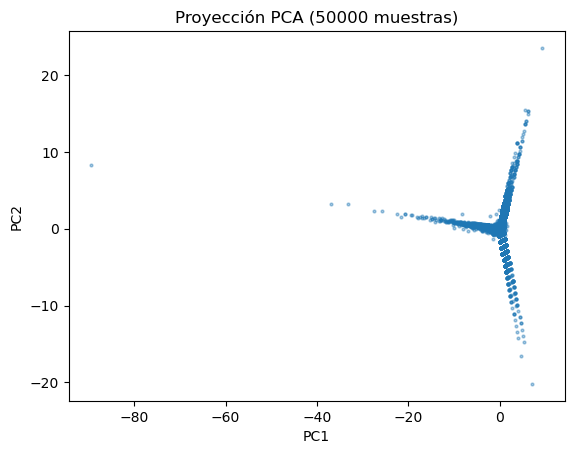

In [6]:
num_cols_pca = ["hora_cod", "num_vehiculos", "num_lesionados", "num_fallecidos", "num_accidentes"]
va_pca = VectorAssembler(inputCols=num_cols_pca, outputCol="num_features")
scaler_pca = StandardScaler(inputCol="num_features", outputCol="num_features_std", withMean=True, withStd=True)
pca = PCA(k=2, inputCol="num_features_std", outputCol="pca2")
pca_pipe = Pipeline(stages=[va_pca, scaler_pca, pca])
pca_model = pca_pipe.fit(combined.na.fill(0))
pca_df = pca_model.transform(combined.na.fill(0)).select("pca2")
pdf = pca_df.limit(50000).toPandas()
xs = [float(v[0]) for v in pdf["pca2"]]
ys = [float(v[1]) for v in pdf["pca2"]]
plt.figure()
plt.scatter(xs, ys, s=4, alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyección PCA (50000 muestras)")
plt.show()

## Ejercicio 4

In [7]:
features_km = ["hora_cod", "num_vehiculos", "num_lesionados", "num_fallecidos"]
va_km = VectorAssembler(inputCols=features_km, outputCol="km_num")
sc_km = StandardScaler(inputCol="km_num", outputCol="km_num_std", withMean=True, withStd=True)
prep_km = Pipeline(stages=[va_km, sc_km]).fit(combined.na.fill(0))
km_df = prep_km.transform(combined.na.fill(0))

sil_scores = []
for k in [2,3,4,5]:
    km = KMeans(featuresCol="km_num_std", predictionCol=f"cluster_k{k}", k=k, seed=SEED)
    model = km.fit(km_df)
    pred = model.transform(km_df)
    sil = ClusteringEvaluator(featuresCol="km_num_std", predictionCol=f"cluster_k{k}", metricName="silhouette", distanceMeasure="squaredEuclidean").evaluate(pred)
    sil_scores.append((k, sil))
print("Silhouette por k:", sil_scores)

best_k = max(sil_scores, key=lambda x: x[1])[0]
km_best = KMeans(featuresCol="km_num_std", predictionCol="cluster", k=best_k, seed=SEED).fit(km_df)
km_pred = km_best.transform(km_df)

caracterizacion = (
    km_pred.groupBy("cluster")
    .agg(
        F.count(F.lit(1)).alias("n"),
        F.avg("hora_cod").alias("avg_hora"),
        F.avg("num_vehiculos").alias("avg_veh"),
        F.avg("num_lesionados").alias("avg_les"),
        F.avg("num_fallecidos").alias("avg_fall"),
        F.avg("num_accidentes").alias("avg_acc")
    )
    .orderBy("cluster")
)
caracterizacion.show(truncate=False)

Silhouette por k: [(2, 0.40870844343902385), (3, 0.35159063021176723), (4, 0.5085121287182786), (5, 0.5739299658626104)]
+-------+-----+------------------+-------------------+-------------------+-------------------+--------------------+
|cluster|n    |avg_hora          |avg_veh            |avg_les            |avg_fall           |avg_acc             |
+-------+-----+------------------+-------------------+-------------------+-------------------+--------------------+
|0      |77628|3.4415159478538673|0.5936775390323079 |0.5233420930592054 |0.0                |0.5062606276085948  |
|1      |65011|0.7168479180446387|0.7123871344849333 |0.09287659011551891|0.0                |0.5470766485671655  |
|2      |1848 |2.841991341991342 |0.19696969696969696|9.92478354978355   |0.48268398268398266|0.12824675324675325 |
|3      |12180|2.8190476190476192|0.17307060755336617|0.6076354679802956 |1.1633004926108375 |0.1341543513957307  |
|4      |1451 |1.9352170916609235|11.796691936595451 |0.01791867677

## Ejercicio 5

In [8]:
def severidad_udf(les, fall):
    if fall is None: fall = 0
    if les is None: les = 0
    if (fall > 1) or (les > 5):
        return "grave"
    if (fall == 1) or (2 <= les <= 5):
        return "moderado"
    return "leve"

sev = F.udf(severidad_udf, T.StringType())
data_cls = combined.withColumn("severidad", sev(F.col("num_lesionados"), F.col("num_fallecidos")))
data_cls.groupBy("severidad").count().orderBy("count", ascending=False).show()

+---------+------+
|severidad| count|
+---------+------+
|     leve|133435|
| moderado| 21427|
|    grave|  3256|
+---------+------+



## Ejercicio 6

In [9]:
train, test = data_cls.randomSplit([0.7, 0.3], seed=SEED)

## Ejercicio 7

In [17]:
def _sev(les, fall):
    les = 0 if les is None else les
    fall = 0 if fall is None else fall
    if (fall > 1) or (les > 5): return "grave"
    if (fall == 1) or (2 <= les <= 5): return "moderado"
    return "leve"
sev = F.udf(_sev, T.StringType())
data_cls = combined2.withColumn("severidad", sev(F.col("num_lesionados"), F.col("num_fallecidos")))

cat_cols = ["tipo_eve", "depto_ocu", "dia_sem_ocu", "mes_ocu"]
num_cols = ["hora_cod", "num_vehiculos", "num_accidentes"]

for c in cat_cols:
    data_cls = data_cls.withColumn(c, F.col(c).cast("string"))
for c in num_cols:
    data_cls = data_cls.withColumn(c, F.col(c).cast("double"))

imputer_sup = Imputer(strategy="median",
                      inputCols=num_cols,
                      outputCols=[f"{c}_imp" for c in num_cols])

idxers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in cat_cols]
label_idx = StringIndexer(inputCol="severidad", outputCol="label", handleInvalid="keep")

va_sup = VectorAssembler(
    inputCols=[f"{c}_idx" for c in cat_cols] + [f"{c}_imp" for c in num_cols],
    outputCol="sup_in"
)
sc_sup = StandardScaler(inputCol="sup_in", outputCol="features", withMean=True, withStd=True)

train, test = data_cls.randomSplit([0.7, 0.3], seed=SEED)

rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=SEED, numTrees=120, maxDepth=12)
pipe_rf = Pipeline(stages=idxers + [imputer_sup, label_idx, va_sup, sc_sup, rf])

m_rf = pipe_rf.fit(train)
pred_rf = m_rf.transform(test)

eval_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
eval_f1  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
eval_pr  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
eval_rc  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

metrics_rf = {
    "model":"RandomForest",
    "accuracy": eval_acc.evaluate(pred_rf),
    "precision": eval_pr.evaluate(pred_rf),
    "recall": eval_rc.evaluate(pred_rf),
    "f1": eval_f1.evaluate(pred_rf)
}
print(metrics_rf)

{'model': 'RandomForest', 'accuracy': 0.6802726480145835, 'precision': 0.6844201832046154, 'recall': 0.6802726480145835, 'f1': 0.6610328361969917}


## Ejercicio 8

In [18]:
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=60, regParam=0.05)
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", maxDepth=14, minInstancesPerNode=20, seed=SEED)

pipe_lr = Pipeline(stages=idxers + [imputer_sup, label_idx, va_sup, sc_sup, lr])
pipe_dt = Pipeline(stages=idxers + [imputer_sup, label_idx, va_sup, sc_sup, dt])

m_lr = pipe_lr.fit(train)
m_dt = pipe_dt.fit(train)

pred_lr = m_lr.transform(test)
pred_dt = m_dt.transform(test)

metrics_lr = {
    "model":"LogisticRegression",
    "accuracy": eval_acc.evaluate(pred_lr),
    "precision": eval_pr.evaluate(pred_lr),
    "recall": eval_rc.evaluate(pred_lr),
    "f1": eval_f1.evaluate(pred_lr)
}
metrics_dt = {
    "model":"DecisionTree",
    "accuracy": eval_acc.evaluate(pred_dt),
    "precision": eval_pr.evaluate(pred_dt),
    "recall": eval_rc.evaluate(pred_dt),
    "f1": eval_f1.evaluate(pred_dt)
}

spark.createDataFrame(
    [(metrics_rf["model"], metrics_rf["accuracy"], metrics_rf["precision"], metrics_rf["recall"], metrics_rf["f1"]),
     (metrics_lr["model"], metrics_lr["accuracy"], metrics_lr["precision"], metrics_lr["recall"], metrics_lr["f1"]),
     (metrics_dt["model"], metrics_dt["accuracy"], metrics_dt["precision"], metrics_dt["recall"], metrics_dt["f1"])],
    ["modelo","accuracy","precision","recall","f1"]
).show(truncate=False)

+------------------+------------------+------------------+------------------+------------------+
|modelo            |accuracy          |precision         |recall            |f1                |
+------------------+------------------+------------------+------------------+------------------+
|RandomForest      |0.6802726480145835|0.6844201832046154|0.6802726480145835|0.6610328361969917|
|LogisticRegression|0.5813584845842911|0.6013790141994444|0.581358484584291 |0.5719423058972463|
|DecisionTree      |0.6688594753110882|0.6690651374847576|0.6688594753110881|0.6579752213189247|
+------------------+------------------+------------------+------------------+------------------+



## Ejercicio 9

In [25]:
reg_cat = ["tipo_eve", "mes_ocu", "depto_ocu"]
reg_num = ["num_vehiculos", "num_lesionados", "num_accidentes"]

data_reg = combined2.select(*(reg_cat + reg_num + ["num_fallecidos"]))

for c in reg_cat:
    data_reg = data_reg.withColumn(c, F.col(c).cast("string"))
for c in reg_num + ["num_fallecidos"]:
    data_reg = data_reg.withColumn(c, F.col(c).cast("double"))

imputer_reg = Imputer(strategy="median",
                      inputCols=reg_num + ["num_fallecidos"],
                      outputCols=[f"{c}_imp" for c in reg_num + ["num_fallecidos"]])

idx_reg = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in reg_cat]
va_reg  = VectorAssembler(inputCols=[f"{c}_idx" for c in reg_cat] + [f"{c}_imp" for c in reg_num],
                          outputCol="reg_in")
sc_reg  = StandardScaler(inputCol="reg_in", outputCol="features", withMean=True, withStd=True)
lr_reg  = LinearRegression(featuresCol="features", labelCol="num_fallecidos_imp", maxIter=100, regParam=0.1)

pipe_reg = Pipeline(stages=idx_reg + [imputer_reg, va_reg, sc_reg, lr_reg])

train_r, test_r = data_reg.randomSplit([0.7,0.3], seed=SEED)
m_reg = pipe_reg.fit(train_r)
pred_reg = m_reg.transform(test_r)

re_rmse = RegressionEvaluator(labelCol="num_fallecidos_imp", predictionCol="prediction", metricName="rmse")
re_mae  = RegressionEvaluator(labelCol="num_fallecidos_imp", predictionCol="prediction", metricName="mae")
re_r2   = RegressionEvaluator(labelCol="num_fallecidos_imp", predictionCol="prediction", metricName="r2")
print({"rmse": re_rmse.evaluate(pred_reg),
       "mae":  re_mae.evaluate(pred_reg),
       "r2":   re_r2.evaluate(pred_reg)})

{'rmse': 5.069998150073602, 'mae': 1.7303434629992653, 'r2': 0.8683181721314663}


## Ejercicio 10

In [22]:
fl_norm = (
    fl
    .withColumn("anio_ocu", F.coalesce(F.col("anio_ocu"), F.col("anio_ocu_file")).cast("int"))
    .withColumn("mes_ocu", F.col("mes_ocu").cast("int"))
    .withColumn("dia_sem_ocu", F.col("dia_sem_ocu").cast("int"))
    .withColumn("g_hora", F.col("g_hora").cast("int"))
    .withColumn("depto_ocu", F.col("depto_ocu").cast("int"))
    .withColumn("tipo_eve", F.col("tipo_eve").cast("string"))
    .withColumn("fall_raw", F.lower(F.trim(F.col("fall_les").cast("string"))))
    .withColumn(
        "fall_les_norm",
        F.when(F.col("anio_ocu") >= 2022,
               F.when(F.col("fall_raw").isin("1","1.0","1,0"), "fallecimiento")
                .when(F.col("fall_raw").isin("2","2.0","2,0"), "lesionado")
                .when(F.col("fall_raw").isin("3","3.0","3,0"), "ignorado")
                .otherwise(F.col("fall_raw"))
        ).otherwise(
            F.when(F.col("fall_raw").contains("fallec"), "fallecimiento")
             .when(F.col("fall_raw").contains("les"), "lesionado")
             .otherwise("ignorado")
        )
    )
)

key_base = ["anio_ocu","mes_ocu","depto_ocu","tipo_eve"]

fl_counts2 = (
    fl_norm
    .withColumn("is_les",  F.when(F.col("fall_les_norm")=="lesionado",      1).otherwise(0))
    .withColumn("is_fall", F.when(F.col("fall_les_norm")=="fallecimiento",  1).otherwise(0))
    .groupBy(*key_base)
    .agg(F.sum("is_les").alias("num_lesionados"),
         F.sum("is_fall").alias("num_fallecidos"))
)

combined2 = (
    hechos_norm.groupBy(*key_base).agg(F.count(F.lit(1)).alias("num_accidentes"))
    .join(veh_norm.groupBy(*key_base).agg(F.count(F.lit(1)).alias("num_vehiculos")), on=key_base, how="outer")
    .join(fl_counts2, on=key_base, how="outer")
    .fillna({"num_accidentes":0, "num_vehiculos":0, "num_lesionados":0, "num_fallecidos":0})
)

print("Filas 2023 con fallecidos>0:",
      combined2.filter((F.col("anio_ocu")==2023) & (F.col("num_fallecidos")>0)).count())


Filas 2023 con fallecidos>0: 741


In [26]:
MODEL_DIR = os.path.join(PARQ, "models_fix3")
os.makedirs(MODEL_DIR, exist_ok=True)
reg_path = os.path.join(MODEL_DIR, "linreg_fallecidos.model")

m_reg.write().overwrite().save(reg_path)
m_reg2 = PipelineModel.load(reg_path)

df_2023 = combined2.filter(F.col("anio_ocu")==2023)
for c in reg_cat:
    df_2023 = df_2023.withColumn(c, F.col(c).cast("string"))
for c in reg_num + ["num_fallecidos"]:
    df_2023 = df_2023.withColumn(c, F.col(c).cast("double"))
df_2023 = df_2023.na.fill(0, subset=reg_num + ["num_fallecidos"])

print("2023 con fallecidos > 0:",
      df_2023.filter(F.col("num_fallecidos")>0).count())

pred_2023 = m_reg2.transform(df_2023)
pred_2023.select("anio_ocu","mes_ocu","depto_ocu","tipo_eve",
                 "num_vehiculos","num_lesionados","num_accidentes",
                 "num_fallecidos","prediction") \
         .orderBy(F.desc("num_fallecidos"), F.desc("prediction")) \
         .show(30, truncate=False)


2023 con fallecidos > 0: 741
+--------+-------+---------+--------+-------------+--------------+--------------+--------------+------------------+
|anio_ocu|mes_ocu|depto_ocu|tipo_eve|num_vehiculos|num_lesionados|num_accidentes|num_fallecidos|prediction        |
+--------+-------+---------+--------+-------------+--------------+--------------+--------------+------------------+
|2023    |11.0   |1        |5.0     |72.0         |53.0          |72.0          |27.0          |10.025669190641125|
|2023    |12.0   |1        |5.0     |106.0        |93.0          |106.0         |24.0          |16.610610099734657|
|2023    |4.0    |5        |1.0     |98.0         |65.0          |69.0          |21.0          |11.837945786945149|
|2023    |7.0    |1        |5.0     |73.0         |59.0          |73.0          |21.0          |10.063258596105374|
|2023    |12.0   |1        |1.0     |328.0        |210.0         |167.0         |20.0          |29.59877485538651 |
|2023    |3.0    |1        |1.0     |298.0 

## Ejercicio 11

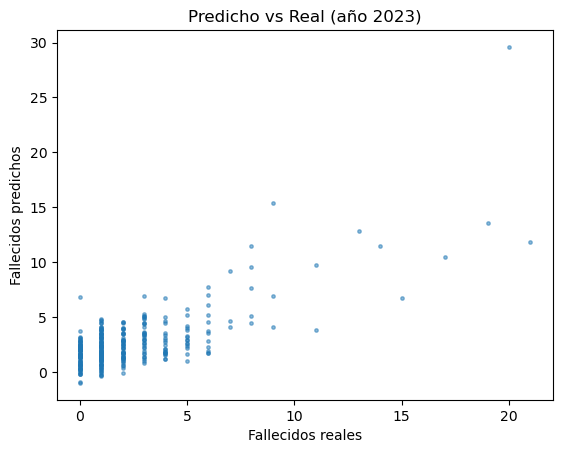

In [27]:
pdf_2023 = (
    pred_2023
    .select(F.col("num_fallecidos").cast("double").alias("real"),
            F.col("prediction").cast("double").alias("pred"))
    .sample(False, 0.35, seed=SEED)
    .limit(50000)
    .toPandas()
)

plt.figure()
plt.scatter(pdf_2023["real"], pdf_2023["pred"], s=6, alpha=0.5)
plt.xlabel("Fallecidos reales")
plt.ylabel("Fallecidos predichos")
plt.title("Predicho vs Real (año 2023)")
plt.show()